In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
from sklearn import datasets 
from sklearn.decomposition import PCA
from sklearn import ensemble

In [ ]:
# let check the number of unique target(labels or categories)
# let verify whether sample point are evenlly distributed around the targets. 
# we need the distribution information to decide the metric to use for model evaluation and if we need stratied K-fold for unevenlly distributed data cross validation 
# let apply a simple unsupervise method to see if the data show separaton (here we select a subset of the data). 

In [ ]:
#Checking the data 
train_mnist = pd.read_csv('../input/train_mnist.csv')
df = pd.DataFrame(train_mnist)
df


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [13]:
df["target"].unique()

array([5, 0, 4, 1, 9, 2, 3, 6, 7, 8])

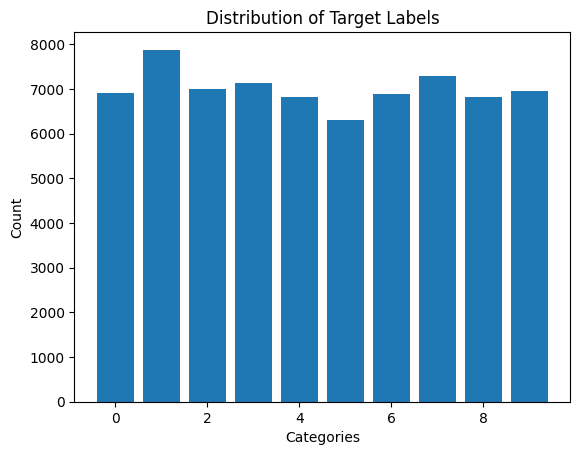

In [32]:
counts =df['target'].value_counts().sort_index()

plt.bar(counts.index, counts.values)
plt.xlabel('Categories')
plt.ylabel('Count')
plt.title('Distribution of Target Labels')
plt.show()

In [33]:
# PCA 
data = df.drop('target', axis=1).values
print(data.shape)
subset_size = data[0:3000,:]
print(subset_size.shape)

data_pca = PCA(n_components=2)
data_pca_2D = data_pca.fit_transform(subset_size)  


(70000, 784)
(3000, 784)


In [35]:
target = df["target"].iloc[0:3000]
#target.shape

data_pca_2D_df = pd.DataFrame(
    np.column_stack((data_pca_2D, target)), 
    columns = ["x", "y", "target"]
)

data_pca_2D_df

,x,y,target
0,163.270456,346.435787,5.0
1,1077.733025,389.656764,0.0
2,-75.701930,-416.942501,4.0
3,-909.504494,617.938360,1.0
4,-344.804423,-716.555382,9.0
...,...,...,...
2995,-263.800933,-837.783088,7.0
2996,1308.055620,264.362654,0.0
2997,-457.945361,-196.700141,9.0
2998,-742.245184,63.131205,1.0


Text(0.5, 0.98, 'data PCA 2D visualization')

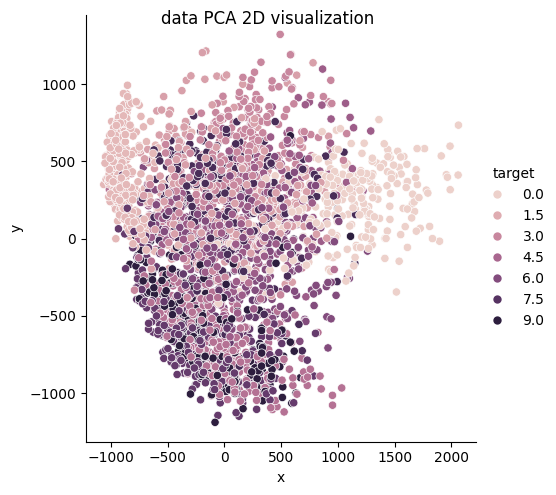

In [36]:
pca_scatter = sns.relplot(data=data_pca_2D_df, x="x", y="y", hue ="target")
pca_scatter.fig.suptitle("data PCA 2D visualization")

In [ ]:
# Evaluation metric include precision, recall, F1-score and AUC etc.

In [44]:
rf_model = ensemble.RandomForestClassifier
type(rf_model)

abc.ABCMeta